# Altimetry time series for Duck

## Paths and settings

In [1]:
# paths jupyter utwente
path_input_general = '/home/jovyan/data/98_paper2_kf_dtm/0_input_general/'
path_input = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/input/'
path_output = '/home/jovyan/data/98_paper2_kf_dtm/21_Duck_altimetry/output/'

https://spatialreference.org/explorer.html?latlng=36.168923,-75.751076&ignoreWorld=true&allowDeprecated=false&authorities=EPSG&activeTypes=PROJECTED_CRS  
https://spatialreference.org/ref/epsg/2264/  
https://spatialreference.org/ref/epsg/32618/  

In [2]:
epsg_in = 4326
epsg_out = 32618 # 32618 2264 local system only required for binning altimetry points into cells
overwrite = False # True: overwrite existing files, False: do not overwrite

## Imports

In [3]:
%load_ext autoreload
%autoreload 2

import os
import xarray as xr
import numpy as np
import pandas as pd
    
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
from cartopy.feature import LAND

from coastal_data import CD_helper_functions, CD_altimetry, CD_data_preparation

import pdb

/home/jovyan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Data

### IB correction

In [4]:
fn = 'ib_correction_era5.nc'
if (not os.path.isfile(path_input_general+fn)) | overwrite:
    corr = CD_altimetry.compute_ib_corr(path_input_general)

ibcorr = xr.open_dataset(path_input_general + fn)

Text(0.5, 1.0, 'IB correction in [m]')

<Figure size 2000x1000 with 0 Axes>

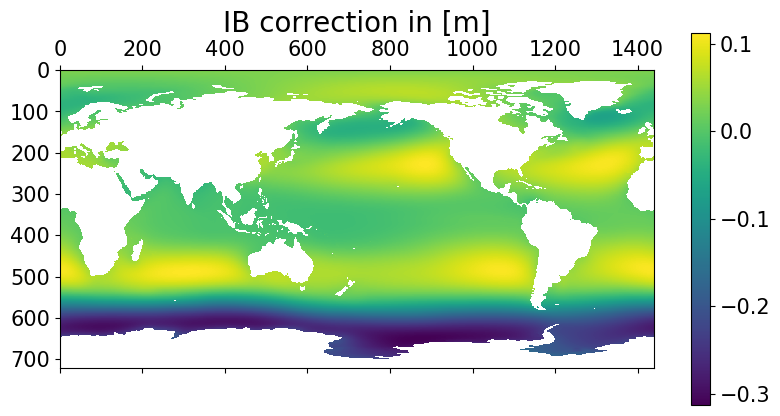

In [5]:
plt.figure(1, figsize=(20,10))
plt.matshow(ibcorr.mean('time').IB_correction)
plt.colorbar()
plt.title('IB correction in [m]')

masked array to xarray, fill value 0, but land areas filled with -20.000  
in the old version (from paper 1), this was automatically 0  
not sure if this affects the correction in the end  
error would be probably so huge that we would see it  

### PSMSL Tide gauge

In [6]:
fn = 'psmsl_monthly_RLR_DUCK.txt'
tg_psmsl_orig = pd.read_csv(f'{path_input}/{fn}', sep=';', header=None, names=['date', 'SSH_RLR[mm]'])

tg_psmsl = pd.DataFrame()
tg_psmsl['date'] = CD_helper_functions.decimal_numbers_to_datetime(tg_psmsl_orig['date'])
tg_psmsl = tg_psmsl.set_index('date')

tg_psmsl['SSH_RLR[cm]'] = tg_psmsl_orig['SSH_RLR[mm]'].values / 10
# if absolute ssh needed, convert RLR to benchmark: https://psmsl.org/data/obtaining/rlr.diagrams/1636.php

# reduce to altimetry time period
tg_psmsl = tg_psmsl.iloc[np.nonzero(tg_psmsl.index.year >= 1992)[0]]

In [7]:
# IB correction
psmsl_lat = 53.363
psmsl_lon = 5.220

psmsl_ibcorr = ibcorr.interp(lat=psmsl_lat, lon=psmsl_lon, method="linear")
time_ib = pd.to_datetime(psmsl_ibcorr.time, utc=True)
values_ib = psmsl_ibcorr.IB_correction

time_psmsl = tg_psmsl.index

ib_at_psmsl_times = np.interp(time_psmsl, time_ib, values_ib)

tg_psmsl['corr_ib[cm]'] = ib_at_psmsl_times * 100

### OpenADB ALES

In [8]:
# Select which missions to use
missions = [
            'Envisat (Version 3)', # 21.06.2002 - 11.10.2010
            'Jason-1',             # 15.01.2002 - 14.01.2009
            # 'Jason-1 (EM)',      # 10.02.2009 - 02.03.2012
            # 'Jason-1 (GM)',      # 11.05.2012 - 17.06.2013
            'Jason-2',             # 12.07.2008 - 30.09.2016
            # 'Jason-2 (EM)',      # 15.10.2016 - 17.05.2017
            'Jason-3',             # 18.02.2016 - 20.04.2019
            'Saral',               # 17.03.2013 - 28.06.2016
            # 'Saral (DP)',        # 05.07.2016 - 14.04.2019
            'Sentinel-3A',         # 24.11.2017 - 04.04.2020
            'Sentinel-3B',         # 26.11.2018 - 12.04.2020
           ]

# Merge all .nc-files
fn = 'ales.nc'
if (not os.path.isfile(path_output + fn)):
    ales = CD_altimetry.combine_openadb_nc_files(path_input + '2_Duck_OpenADB')
    ales = CD_altimetry.select_missions(ales, missions)
    # Clean according to OpenADB instructions (e.g. dist to coast, std, ...)
    ales = CD_altimetry.clean_openadb_ales(ales)
    ales.to_netcdf(path_output + fn)
else:
    ales = xr.open_dataset(path_output + fn)

Cells extracted: 48 49 50 38 39

/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:261: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2002-06-21 15:31:49.945631024+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cell_stats.loc[cell, ('date_min')] = pd.to_datetime(df_red.index.min())
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:262: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2020-04-12 15:33:34+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cell_stats.loc[cell, ('date_max')] = pd.to_datetime(df_red.index.max())


cell
39.0    0.681359
87.0    0.691411
62.0    0.703012
48.0    0.709848
75.0    0.716703
51.0    0.728981
76.0    0.740430
50.0    0.750978
77.0    0.755947
49.0    0.758606
Name: R, dtype: float64
cell
49.0    0.064968
50.0    0.066084
76.0    0.066952
77.0    0.067510
75.0    0.068697
62.0    0.070684
87.0    0.071398
51.0    0.071635
88.0    0.075141
48.0    0.075222
Name: RMSE, dtype: float64
cell
105.0    22.2826
117.0    25.3359
94.0     27.2843
116.0    28.7260
104.0    35.9509
93.0     36.3084
106.0    38.2832
41.0     39.5244
82.0     42.7560
115.0    43.1221
Name: trend_diff, dtype: float64


Enter cell numbers to extract, separated by space (e.g. 96 95 83 82 70 69):  48 49 50 38 39


/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:316: RuntimeWarning: invalid value encountered in scalar divide
  sla_temp_av = (df_month['sla_red'] * weights).sum()/weights.sum()
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:317: RuntimeWarning: invalid value encountered in scalar divide
  ssh_temp_av = (df_month['ssh_red'] * weights).sum()/weights.sum()
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:318: RuntimeWarning: invalid value encountered in scalar divide
  mss_temp_av = (df_month['mssh'] * weights).sum()/weights.sum()


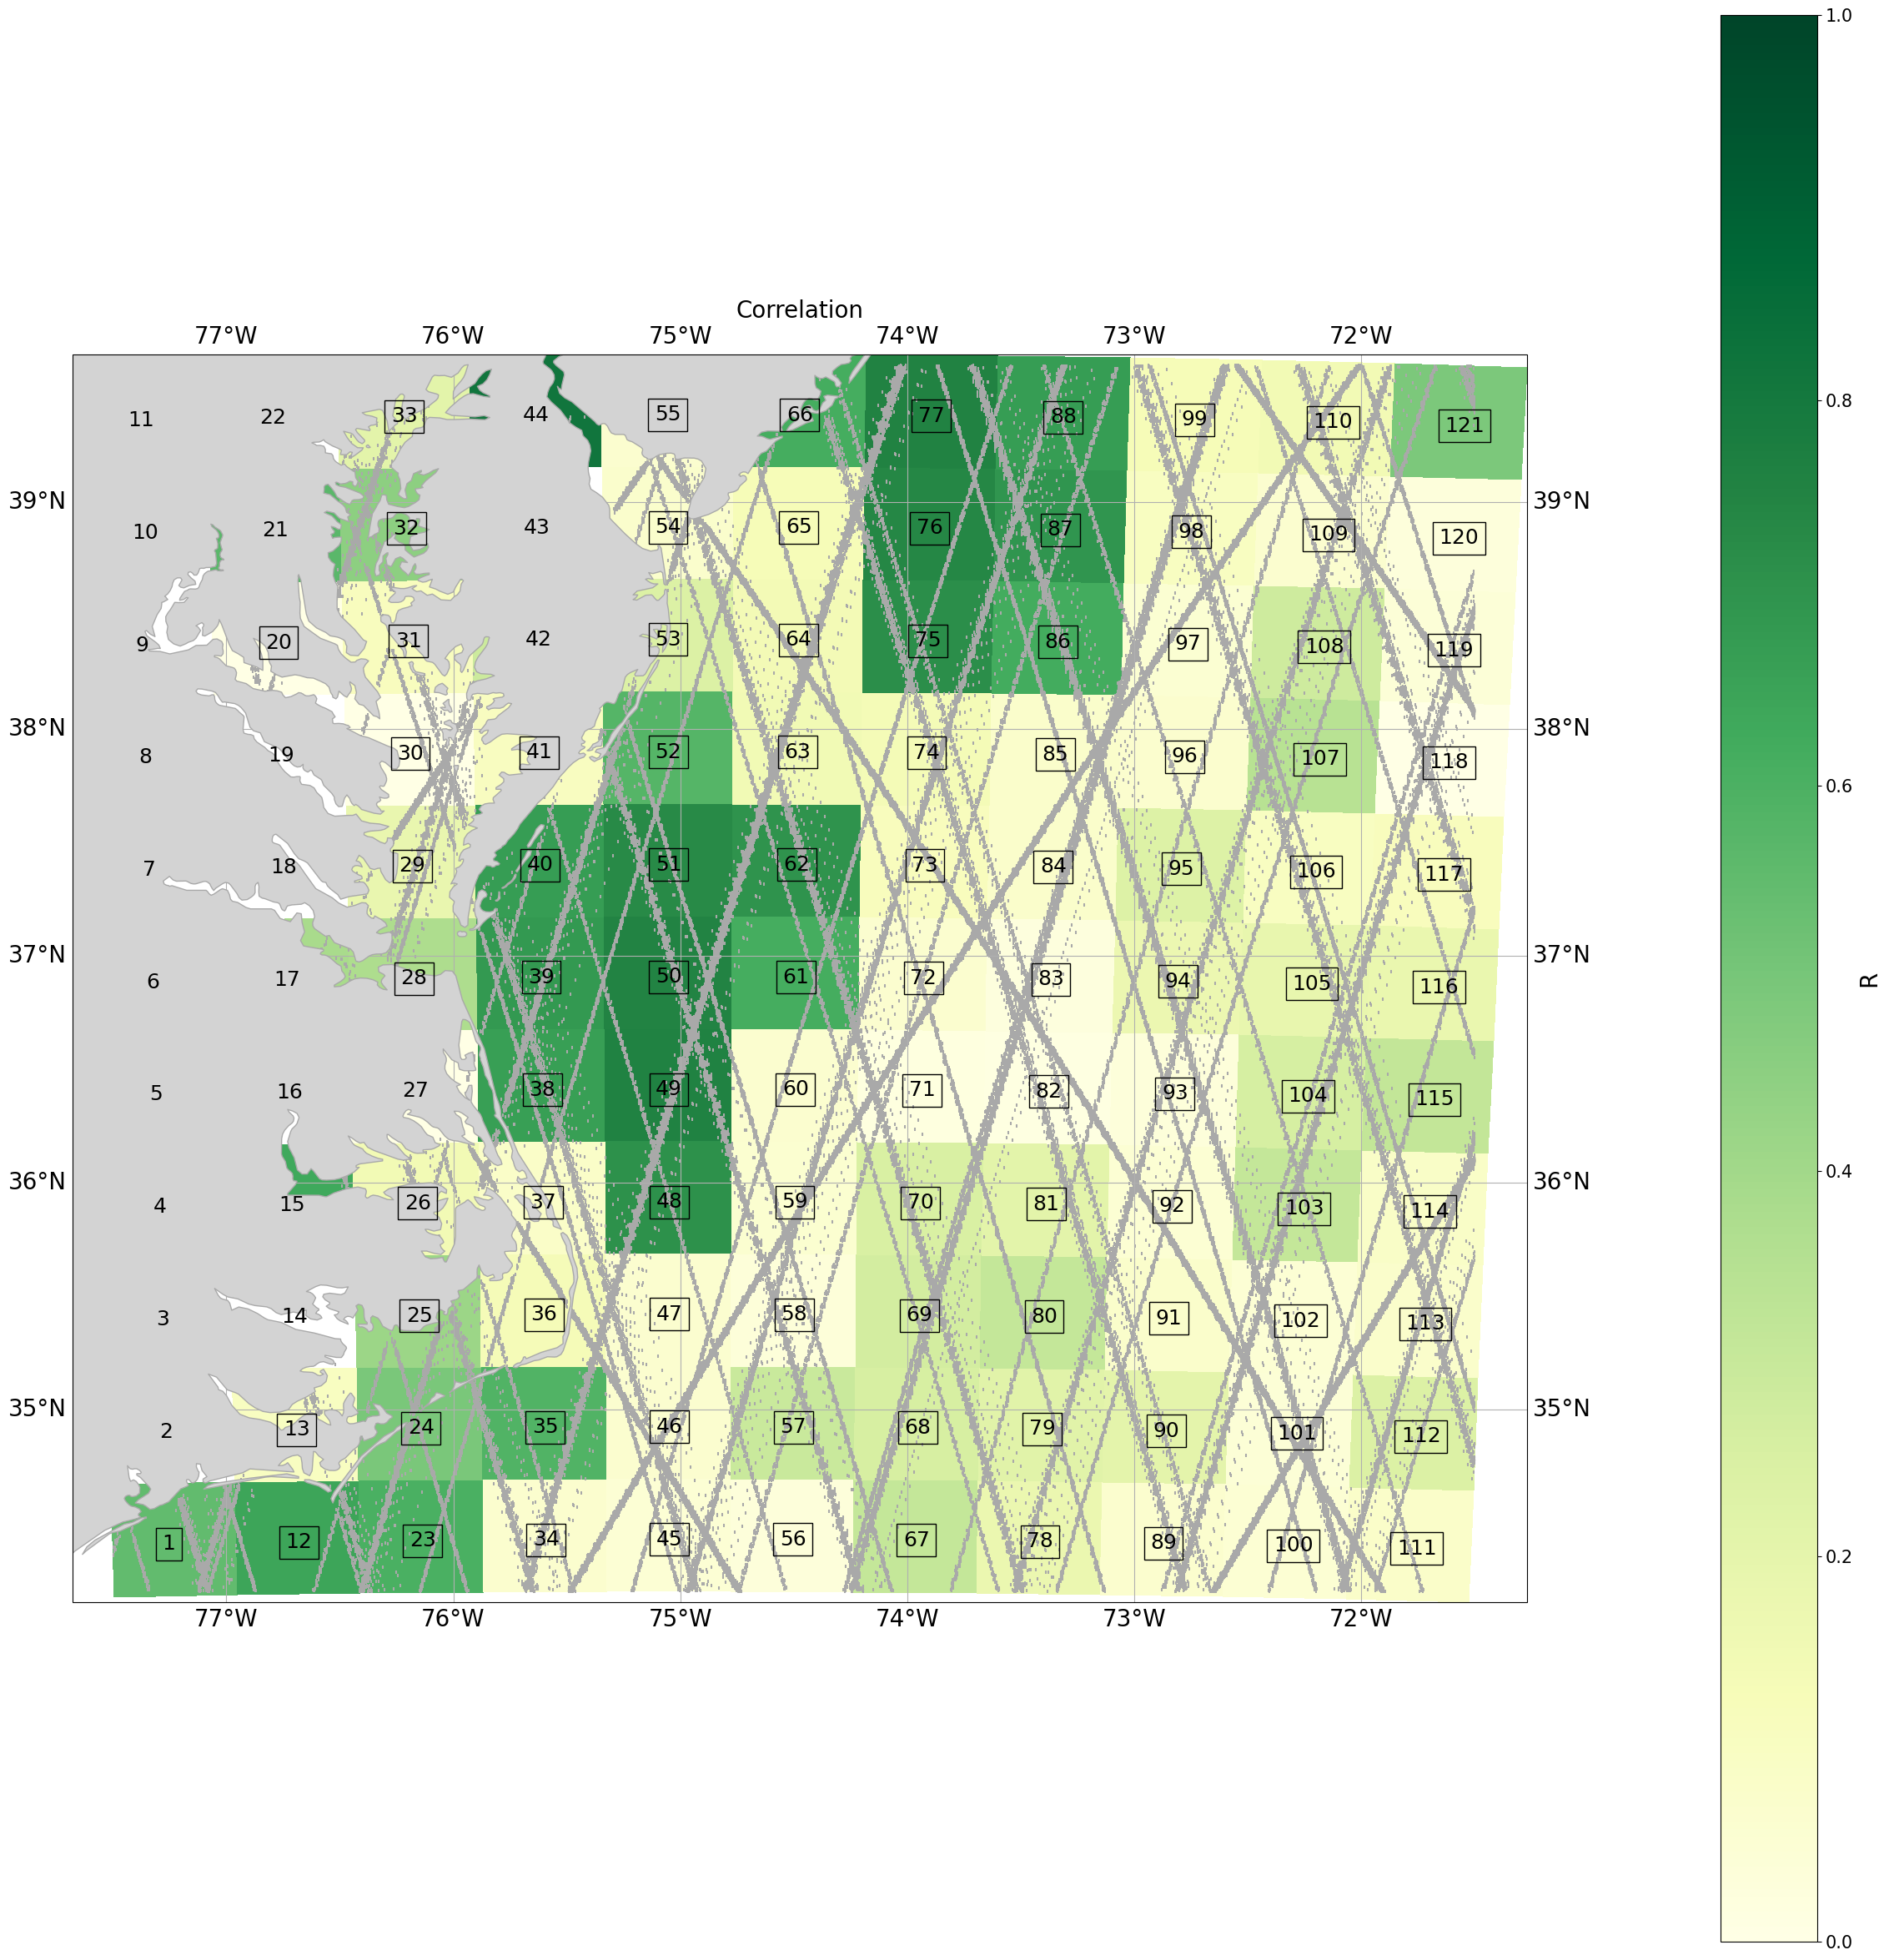

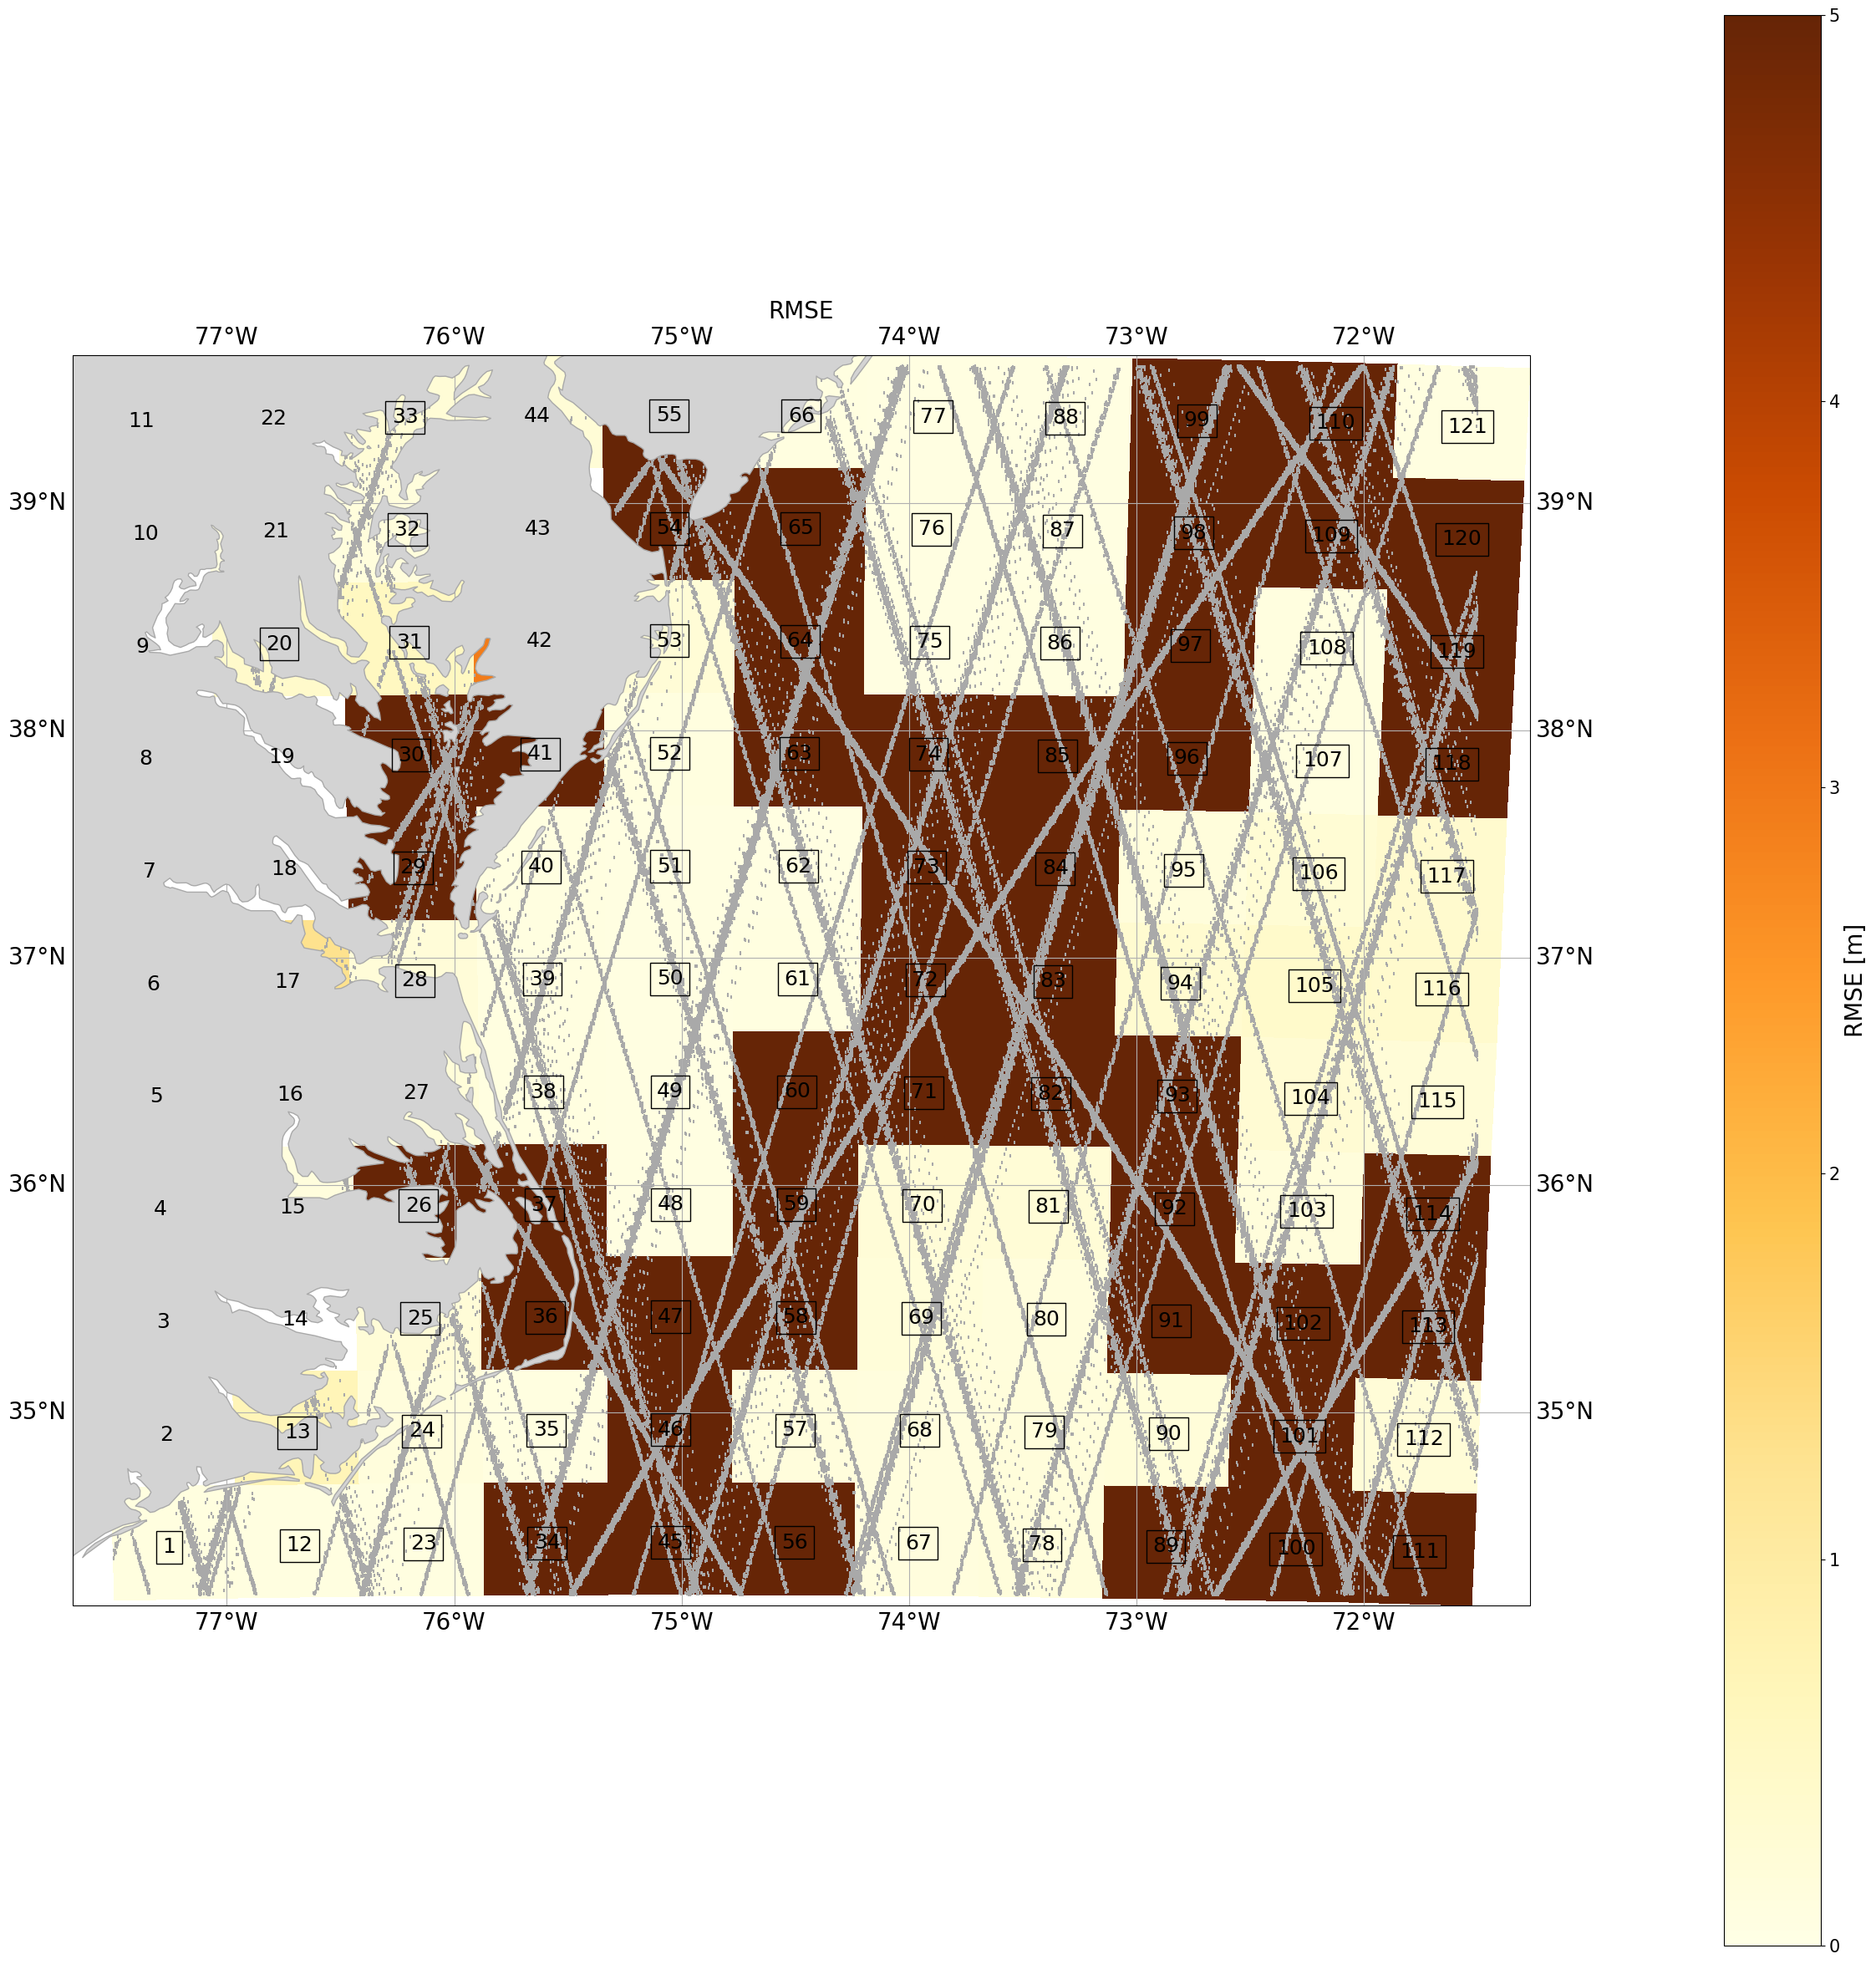

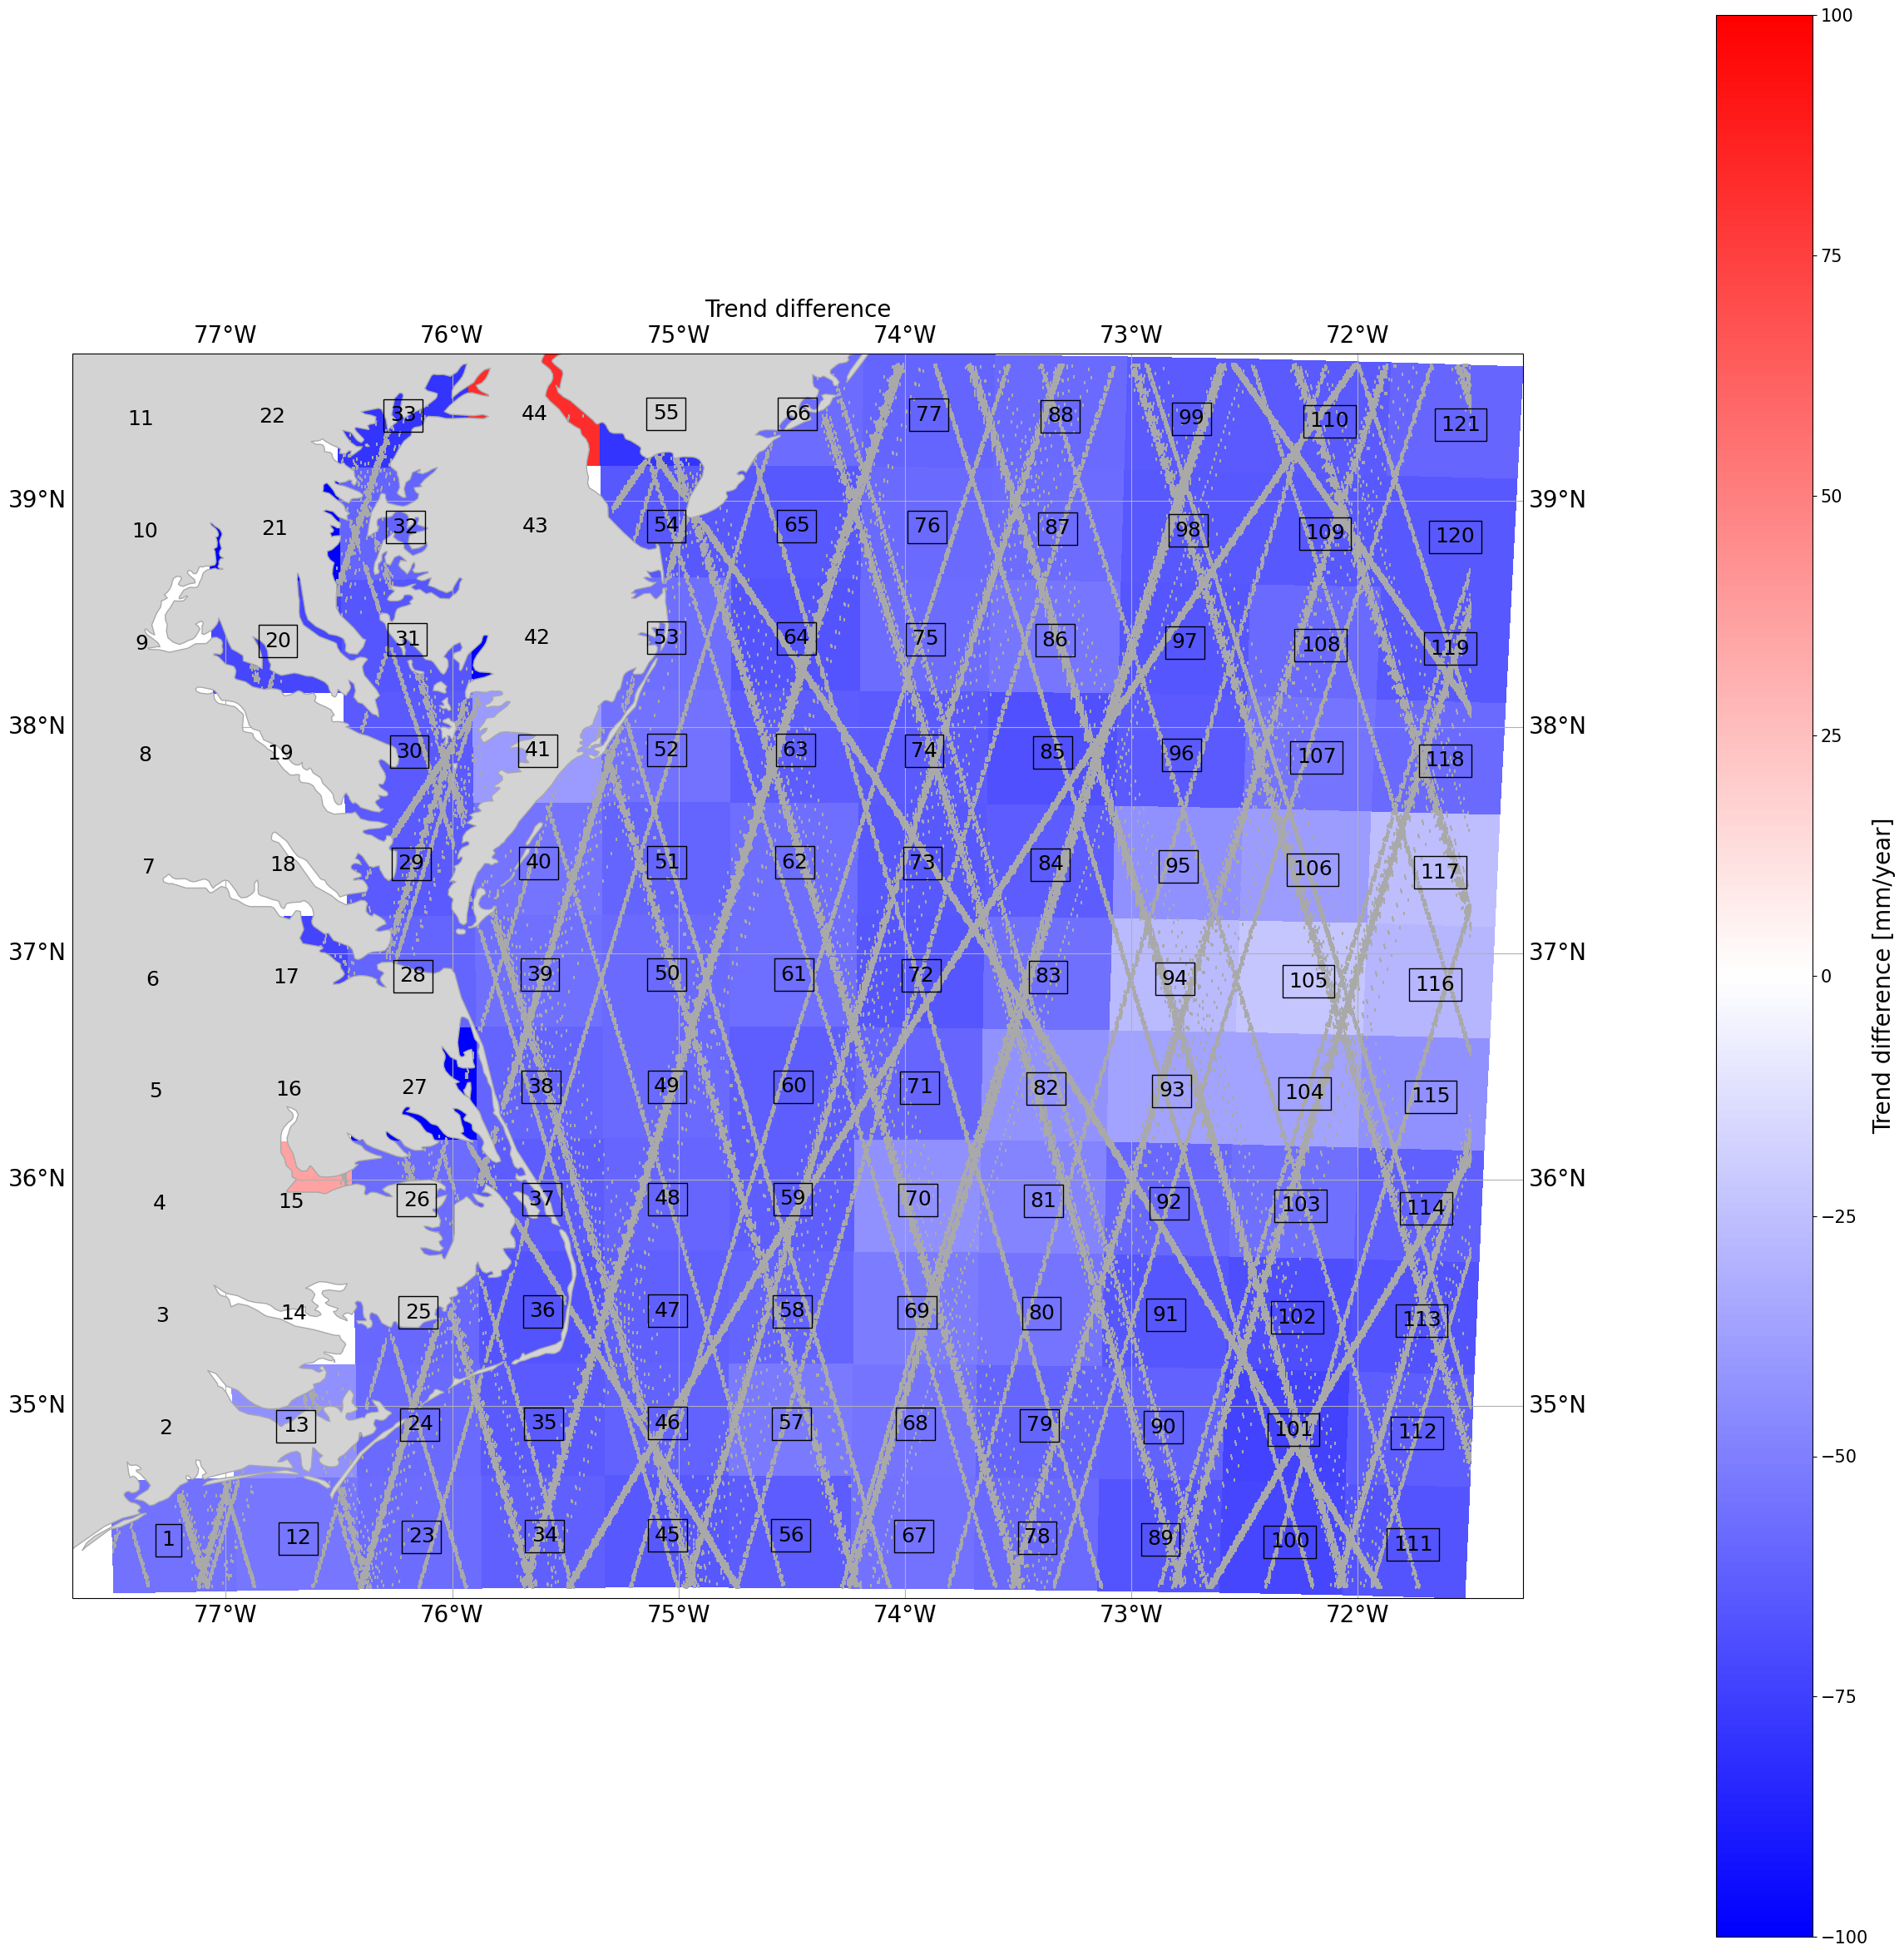

In [12]:
# Make/load timeseries
fn = f'ales_ts_epgs{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    labels = {'time':'time', 'lon':'glon', 'lat':'glat', 'sla':None, 'ssh':'ssh', 'mssh':'mssh'}
    
    tg = tg_psmsl['SSH_RLR[cm]'] - tg_psmsl['corr_ib[cm]']
    
    gridsize = {'x':50, 'y':50} # [km]
    period_covered = {'min':'2003-01-01', 'max':'2020-01-01'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    %matplotlib inline
    ales_ts = CD_altimetry.get_altimetry_timeseries_with_TG(ales, labels, epsg_in, epsg_out, tg, gridsize, period_covered, freq_average)
    ales_ts.to_csv(path_output+fn)
else:
    ales_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

In [13]:
ales_ts

,sla_temp_av,ssh_temp_av,mss_temp_av
time,,,
2002-06-30 00:00:00+00:00,0.000000,0.000000,-39.399000
2002-07-31 00:00:00+00:00,0.055628,-38.316586,-38.372214
2002-08-31 00:00:00+00:00,0.127152,-38.209580,-38.336731
2002-09-30 00:00:00+00:00,0.139991,-38.480450,-38.620441
2002-10-31 00:00:00+00:00,0.250122,-38.417464,-38.667586
...,...,...,...
2019-12-31 00:00:00+00:00,0.065925,-38.613246,-38.679171
2020-01-31 00:00:00+00:00,0.085891,-38.389710,-38.475601
2020-02-29 00:00:00+00:00,0.012910,-38.622359,-38.635269


### RADS T/P

In [10]:
path_tp = f'{path_input}1_marge_topexA_Duck/'
tx_152 = xr.open_dataset(path_tp+'rads2nc_pass152.nc')
tx_167 = xr.open_dataset(path_tp+'rads2nc_pass167.nc')
tx_228 = xr.open_dataset(path_tp+'rads2nc_pass228.nc')
tx_243 = xr.open_dataset(path_tp+'rads2nc_pass243.nc')

tx_combined = xr.merge([tx_152, tx_167, tx_228, tx_243])
tx = CD_altimetry.clean_rads(tx_combined, 'ssha')

Cells extracted for T/P: 45 46 55 54 64 63 (epsg 28992 and epsg 32631) would be the best fitting cells  
80 79 69 68 67 57 would be closer to selection from ALES

In [11]:
tx.time

<xarray.DataArray 'time' (time: 74305)> Size: 594kB
array(['1992-09-29T01:22:43.645923008', '1992-09-29T01:22:44.722695008',
       '1992-09-29T01:22:45.799454976', ..., '2005-10-04T05:22:52.575859072',
       '2005-10-04T05:22:53.653940992', '2005-10-04T05:22:54.732035968'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 594kB 1992-09-29T01:22:43.645923008 ... 20...
    lon      (time) float64 594kB -75.11 -75.08 -75.05 ... -73.53 -73.49 -73.46
    lat      (time) float64 594kB 34.81 34.76 34.71 34.66 ... 39.46 39.51 39.56
Attributes:
    long_name:      time
    standard_name:  time
    field:          101
    comment:        UTC time of measurement. Attribute leap_second gives time...
    created_by:     rads2nc --args rads2nc_arguments

cells extraced (same area as for ALES extracted): 38 39 40 27 28

/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:261: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2002-09-19 16:06:10.584102976+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cell_stats.loc[cell, ('date_min')] = pd.to_datetime(df_red.index.min())
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:262: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2005-09-24 07:22:27.641670016+00:00' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cell_stats.loc[cell, ('date_max')] = pd.to_datetime(df_red.index.max())


cell
52.0    0.214878
36.0    0.222210
88.0    0.224006
49.0    0.229450
87.0    0.230795
81.0    0.232562
60.0    0.251189
63.0    0.252818
62.0    0.287643
61.0    0.305991
Name: R, dtype: float64
cell
48.0    17.676334
47.0    17.680940
49.0    17.694927
53.0    17.917487
52.0    18.196481
25.0    18.756792
34.0    19.127457
24.0    19.269368
35.0    19.711296
79.0    19.930386
Name: RMSE, dtype: float64
cell
49.0     82.0283
48.0     82.1172
53.0     84.5201
52.0     84.5306
47.0     85.2289
89.0    864.5190
90.0    867.1058
79.0    869.6264
23.0    874.3858
80.0    874.5963
Name: trend_diff, dtype: float64


Enter cell numbers to extract, separated by space (e.g. 96 95 83 82 70 69):  38 39 40 27 28


/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_statistics.py:131: RuntimeWarning: Mean of empty slice
  err = ts - np.nanmean(ts)
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_statistics.py:128: RuntimeWarning: Mean of empty slice
  return round(np.sqrt(np.nanmean(ts **2)),3)
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_statistics.py:168: RuntimeWarning: All-NaN slice encountered
  ts_red = ts[np.abs(ts-np.nanmedian(ts)) <= sigma3]
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:316: RuntimeWarning: invalid value encountered in scalar divide
  sla_temp_av = (df_month['sla_red'] * weights).sum()/weights.sum()
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:317: RuntimeWarning: invalid value encountered in scalar divide
  ssh_temp_av = (df_month['ssh_red'] * weights).sum()/weights.sum()
/home/jovyan/git/3_coastal-sea-level/coastal_data/CD_altimetry.py:318: RuntimeWarning: invalid value encountered in scalar divide
  mss_temp_av = (

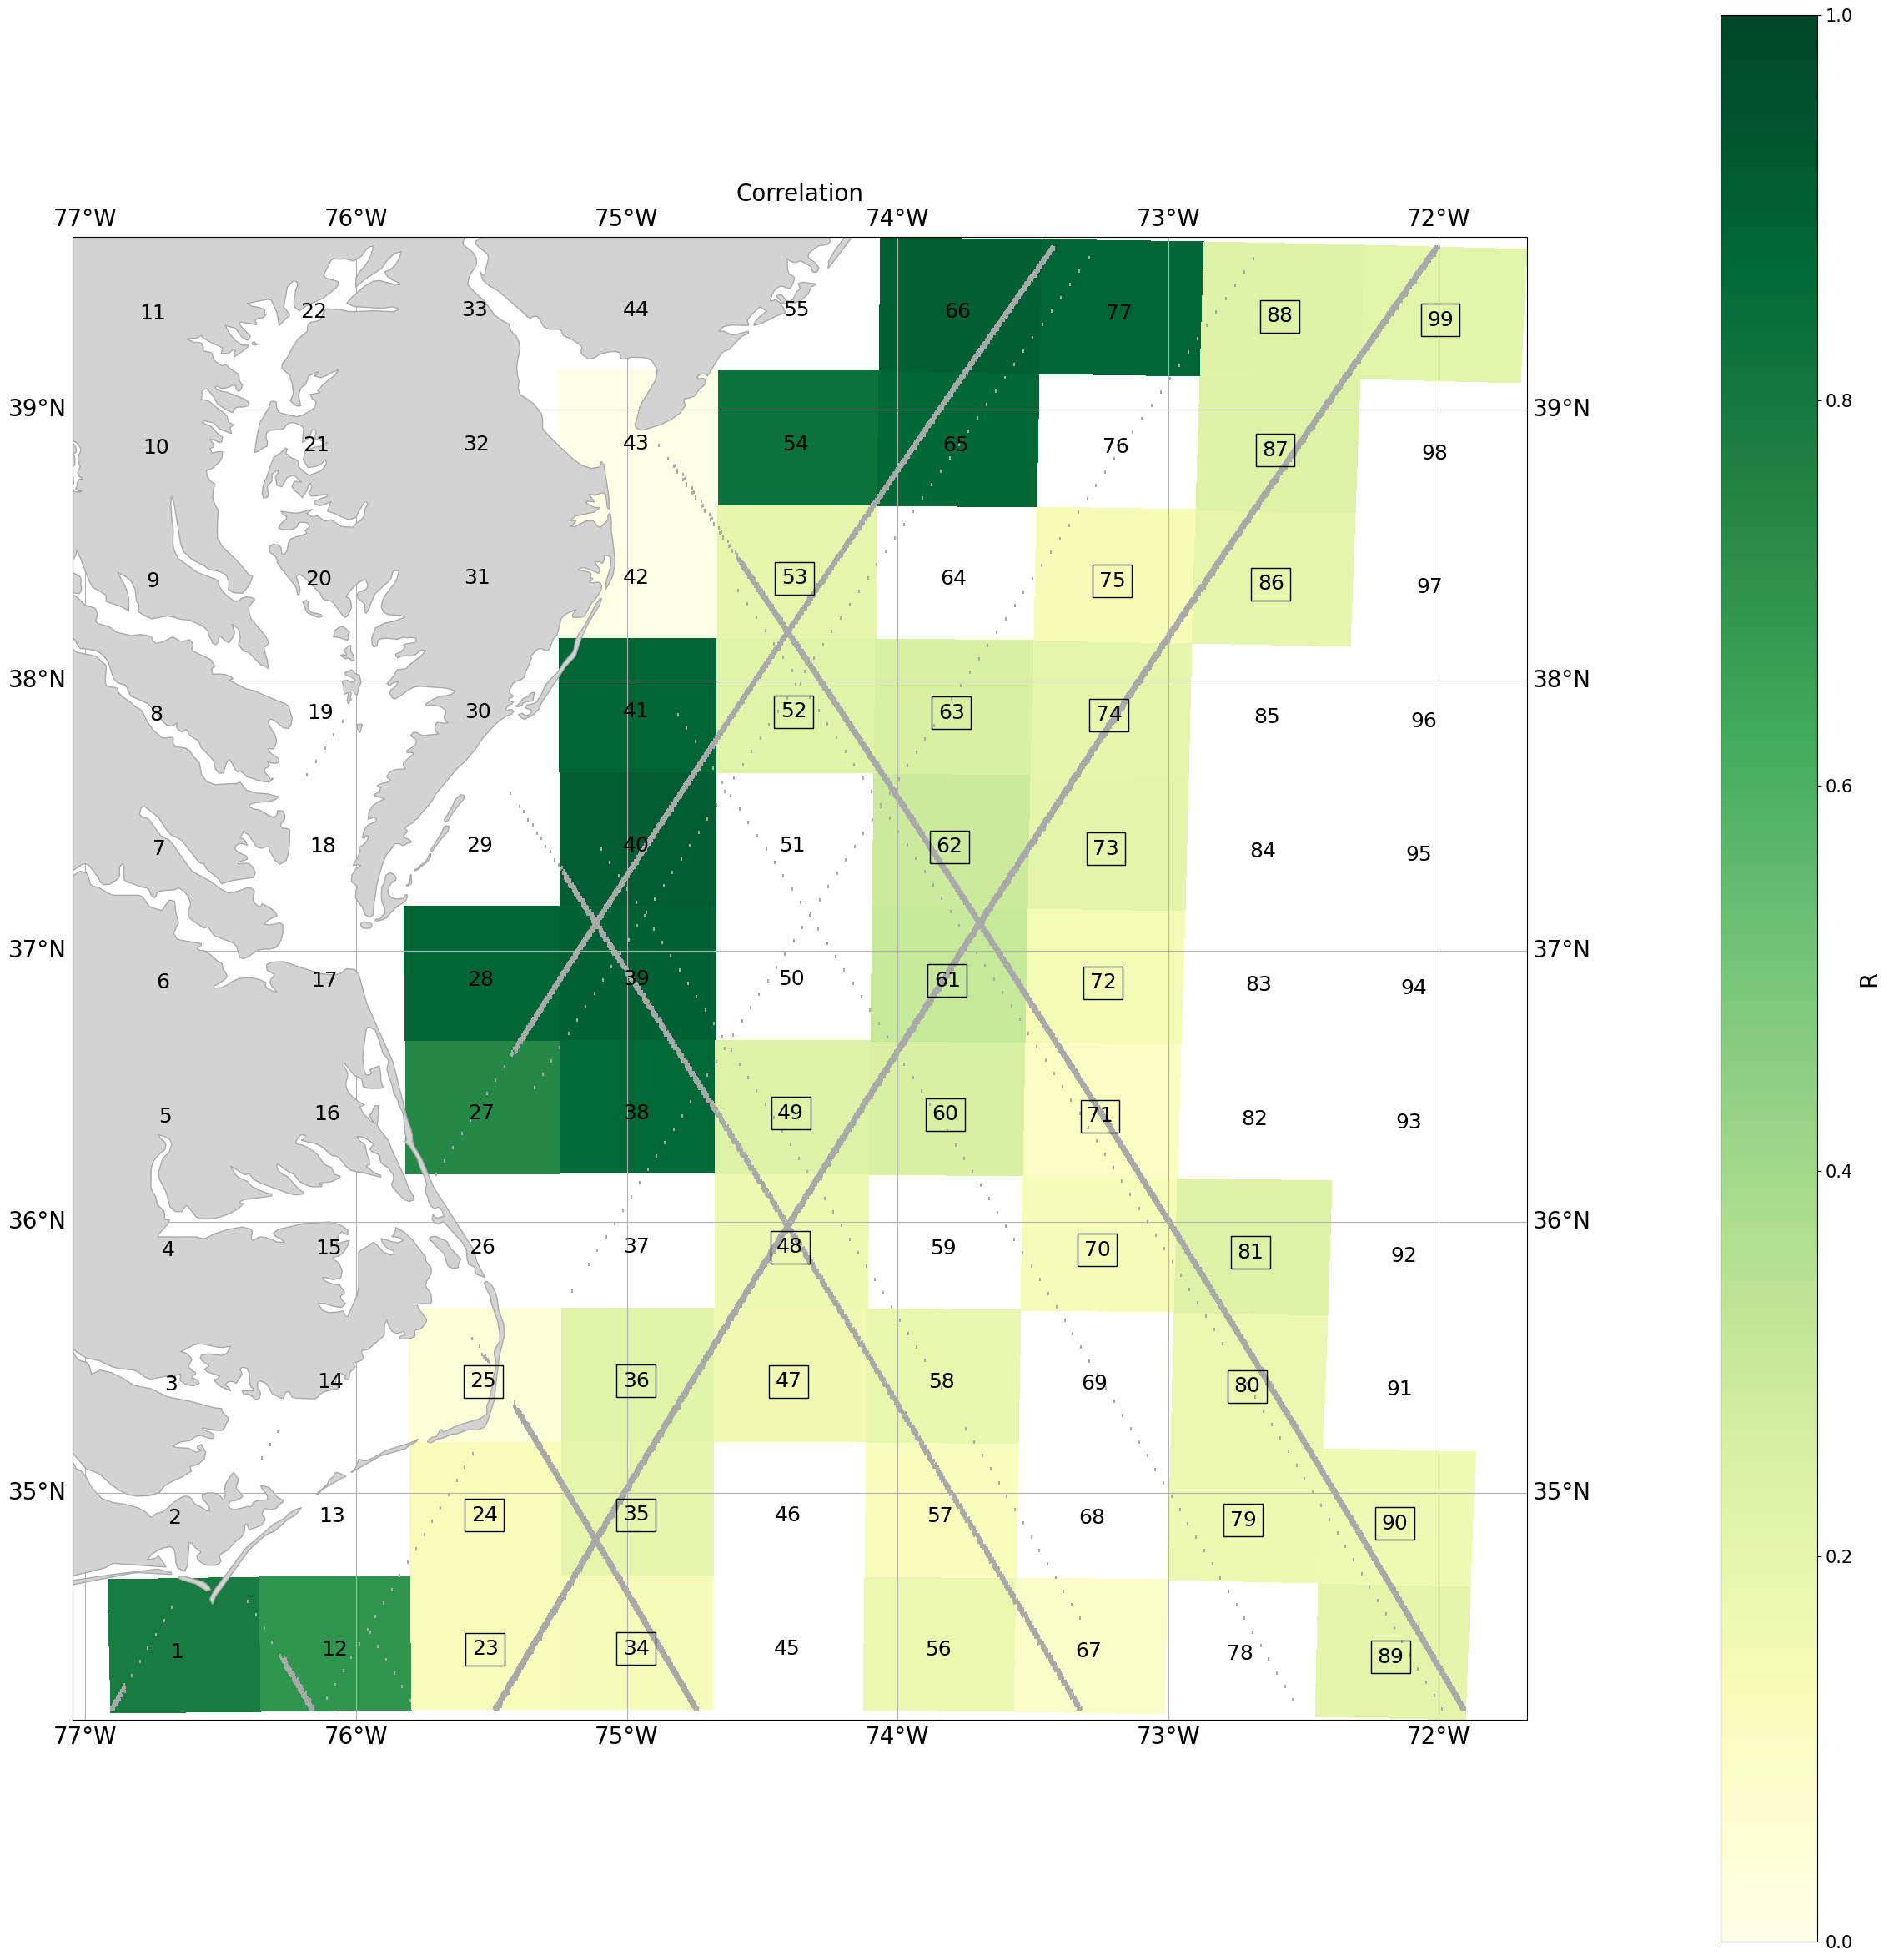

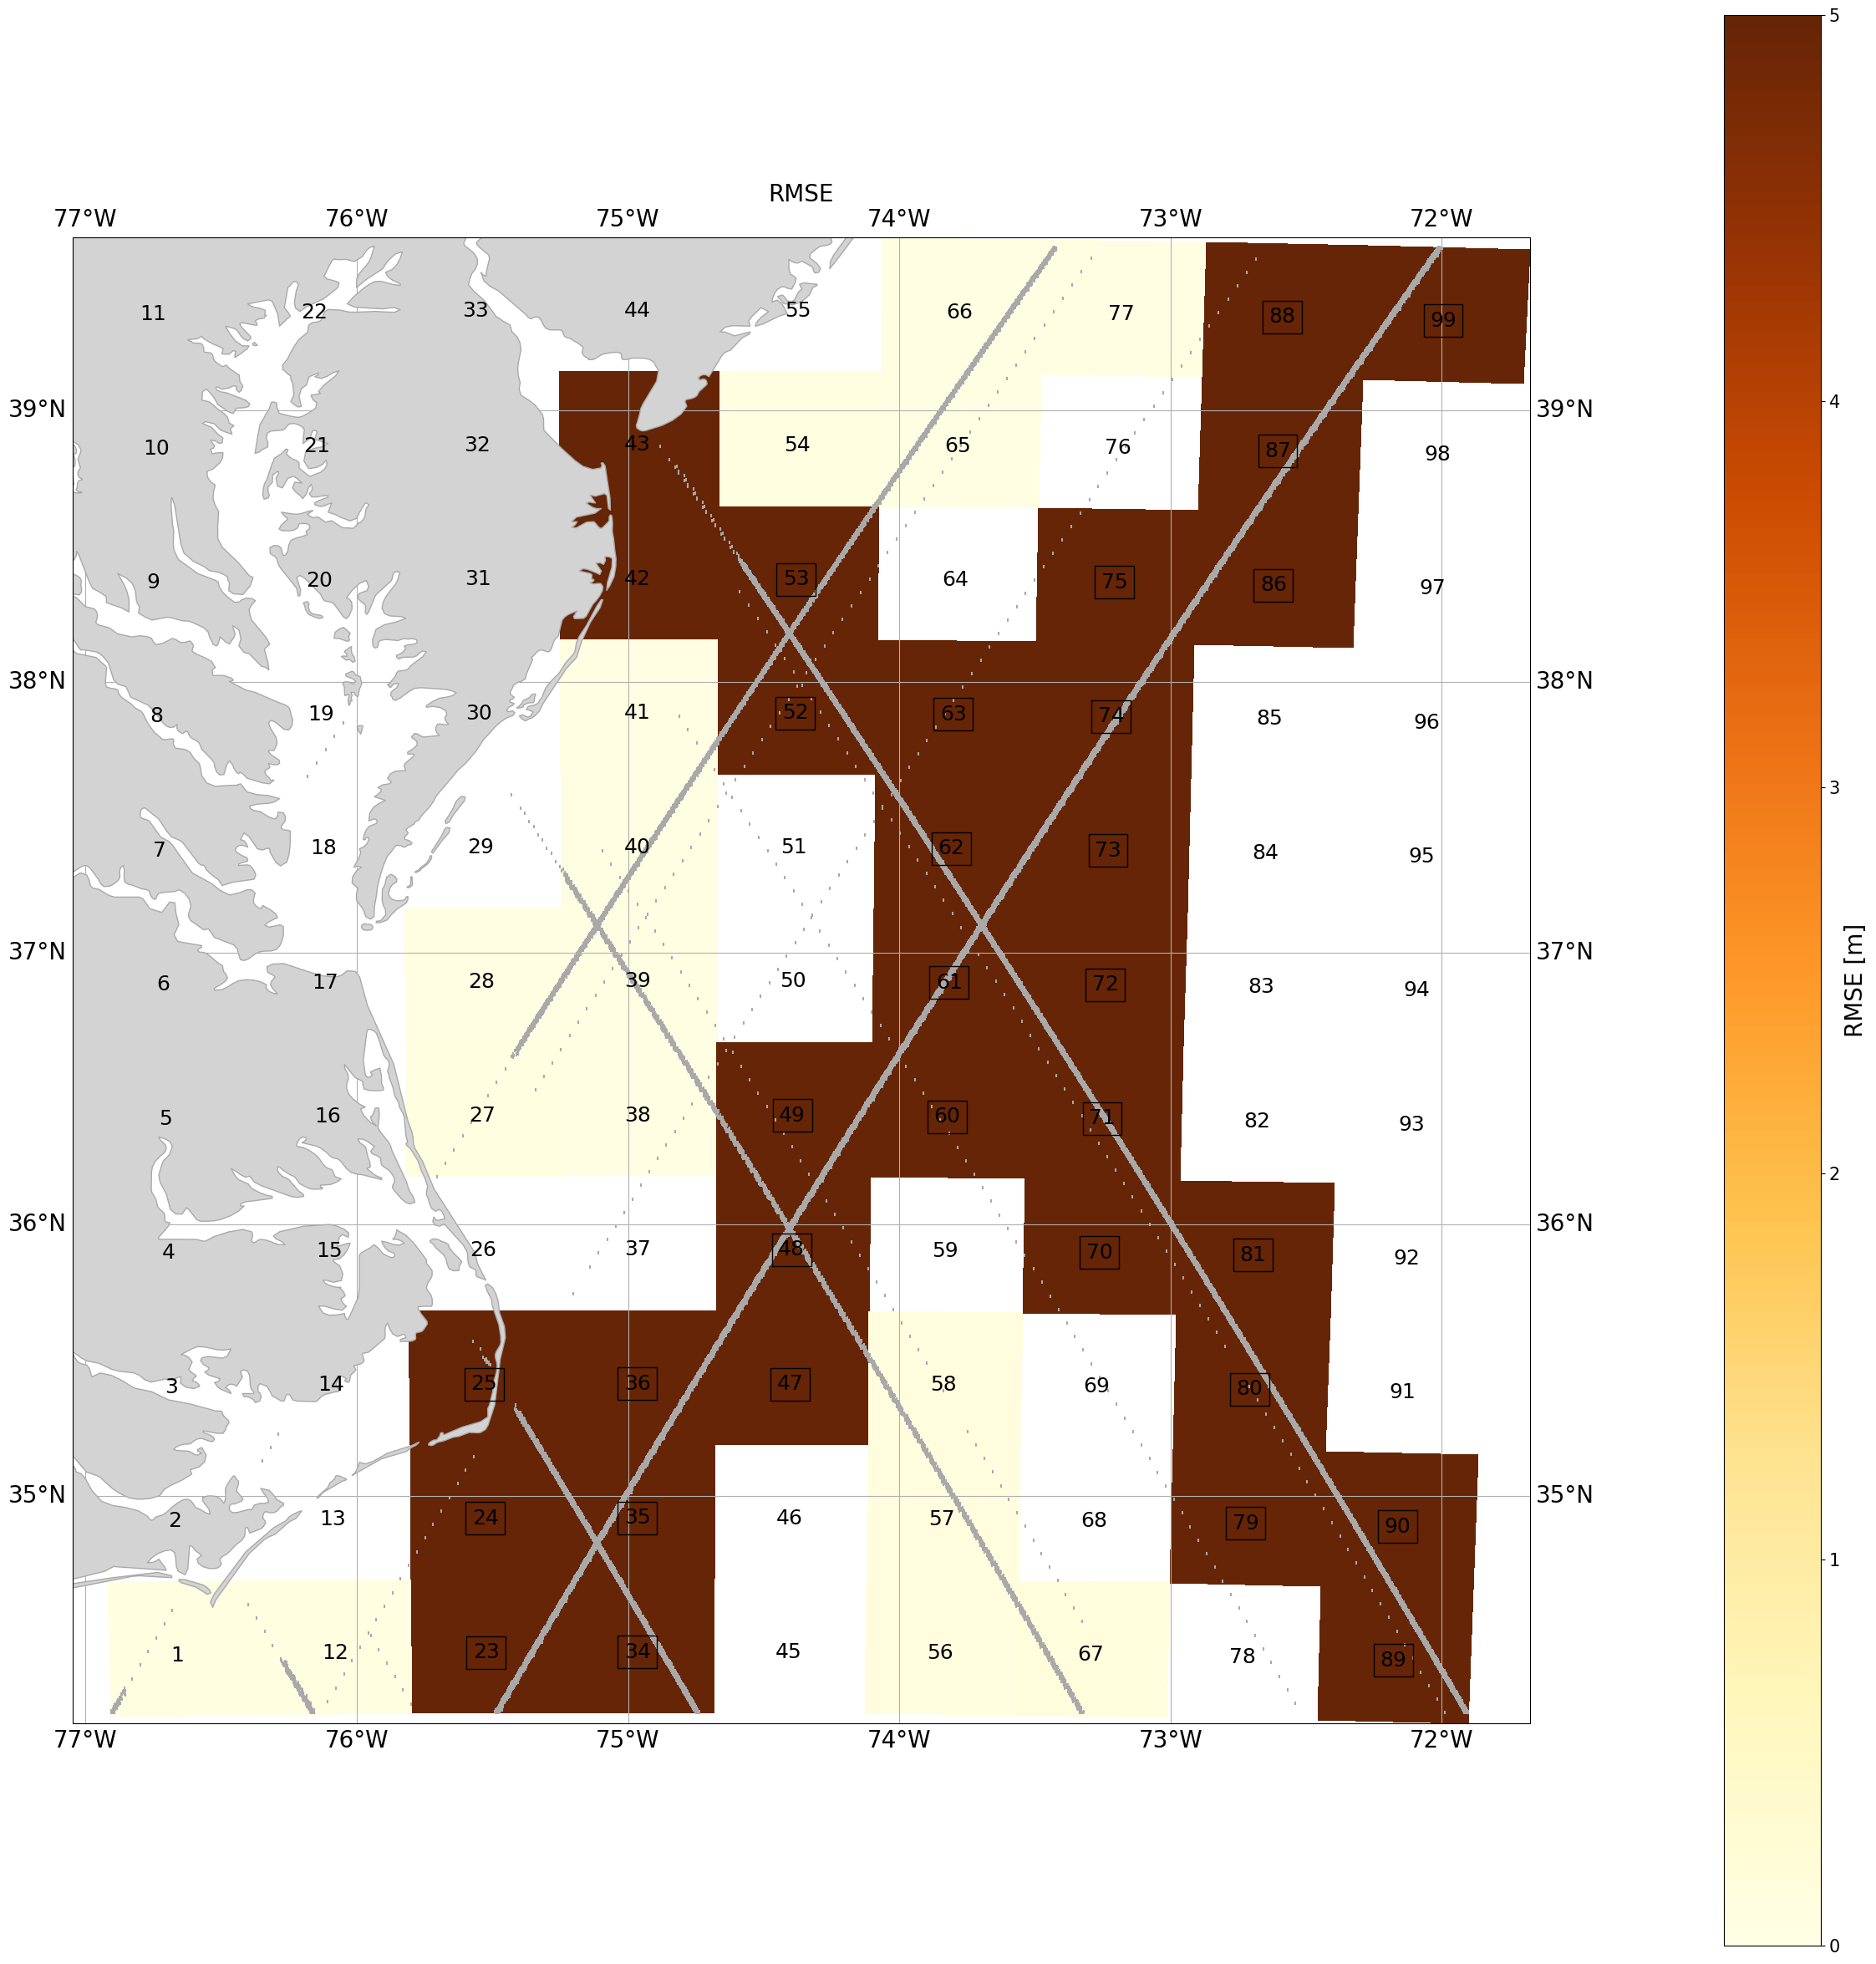

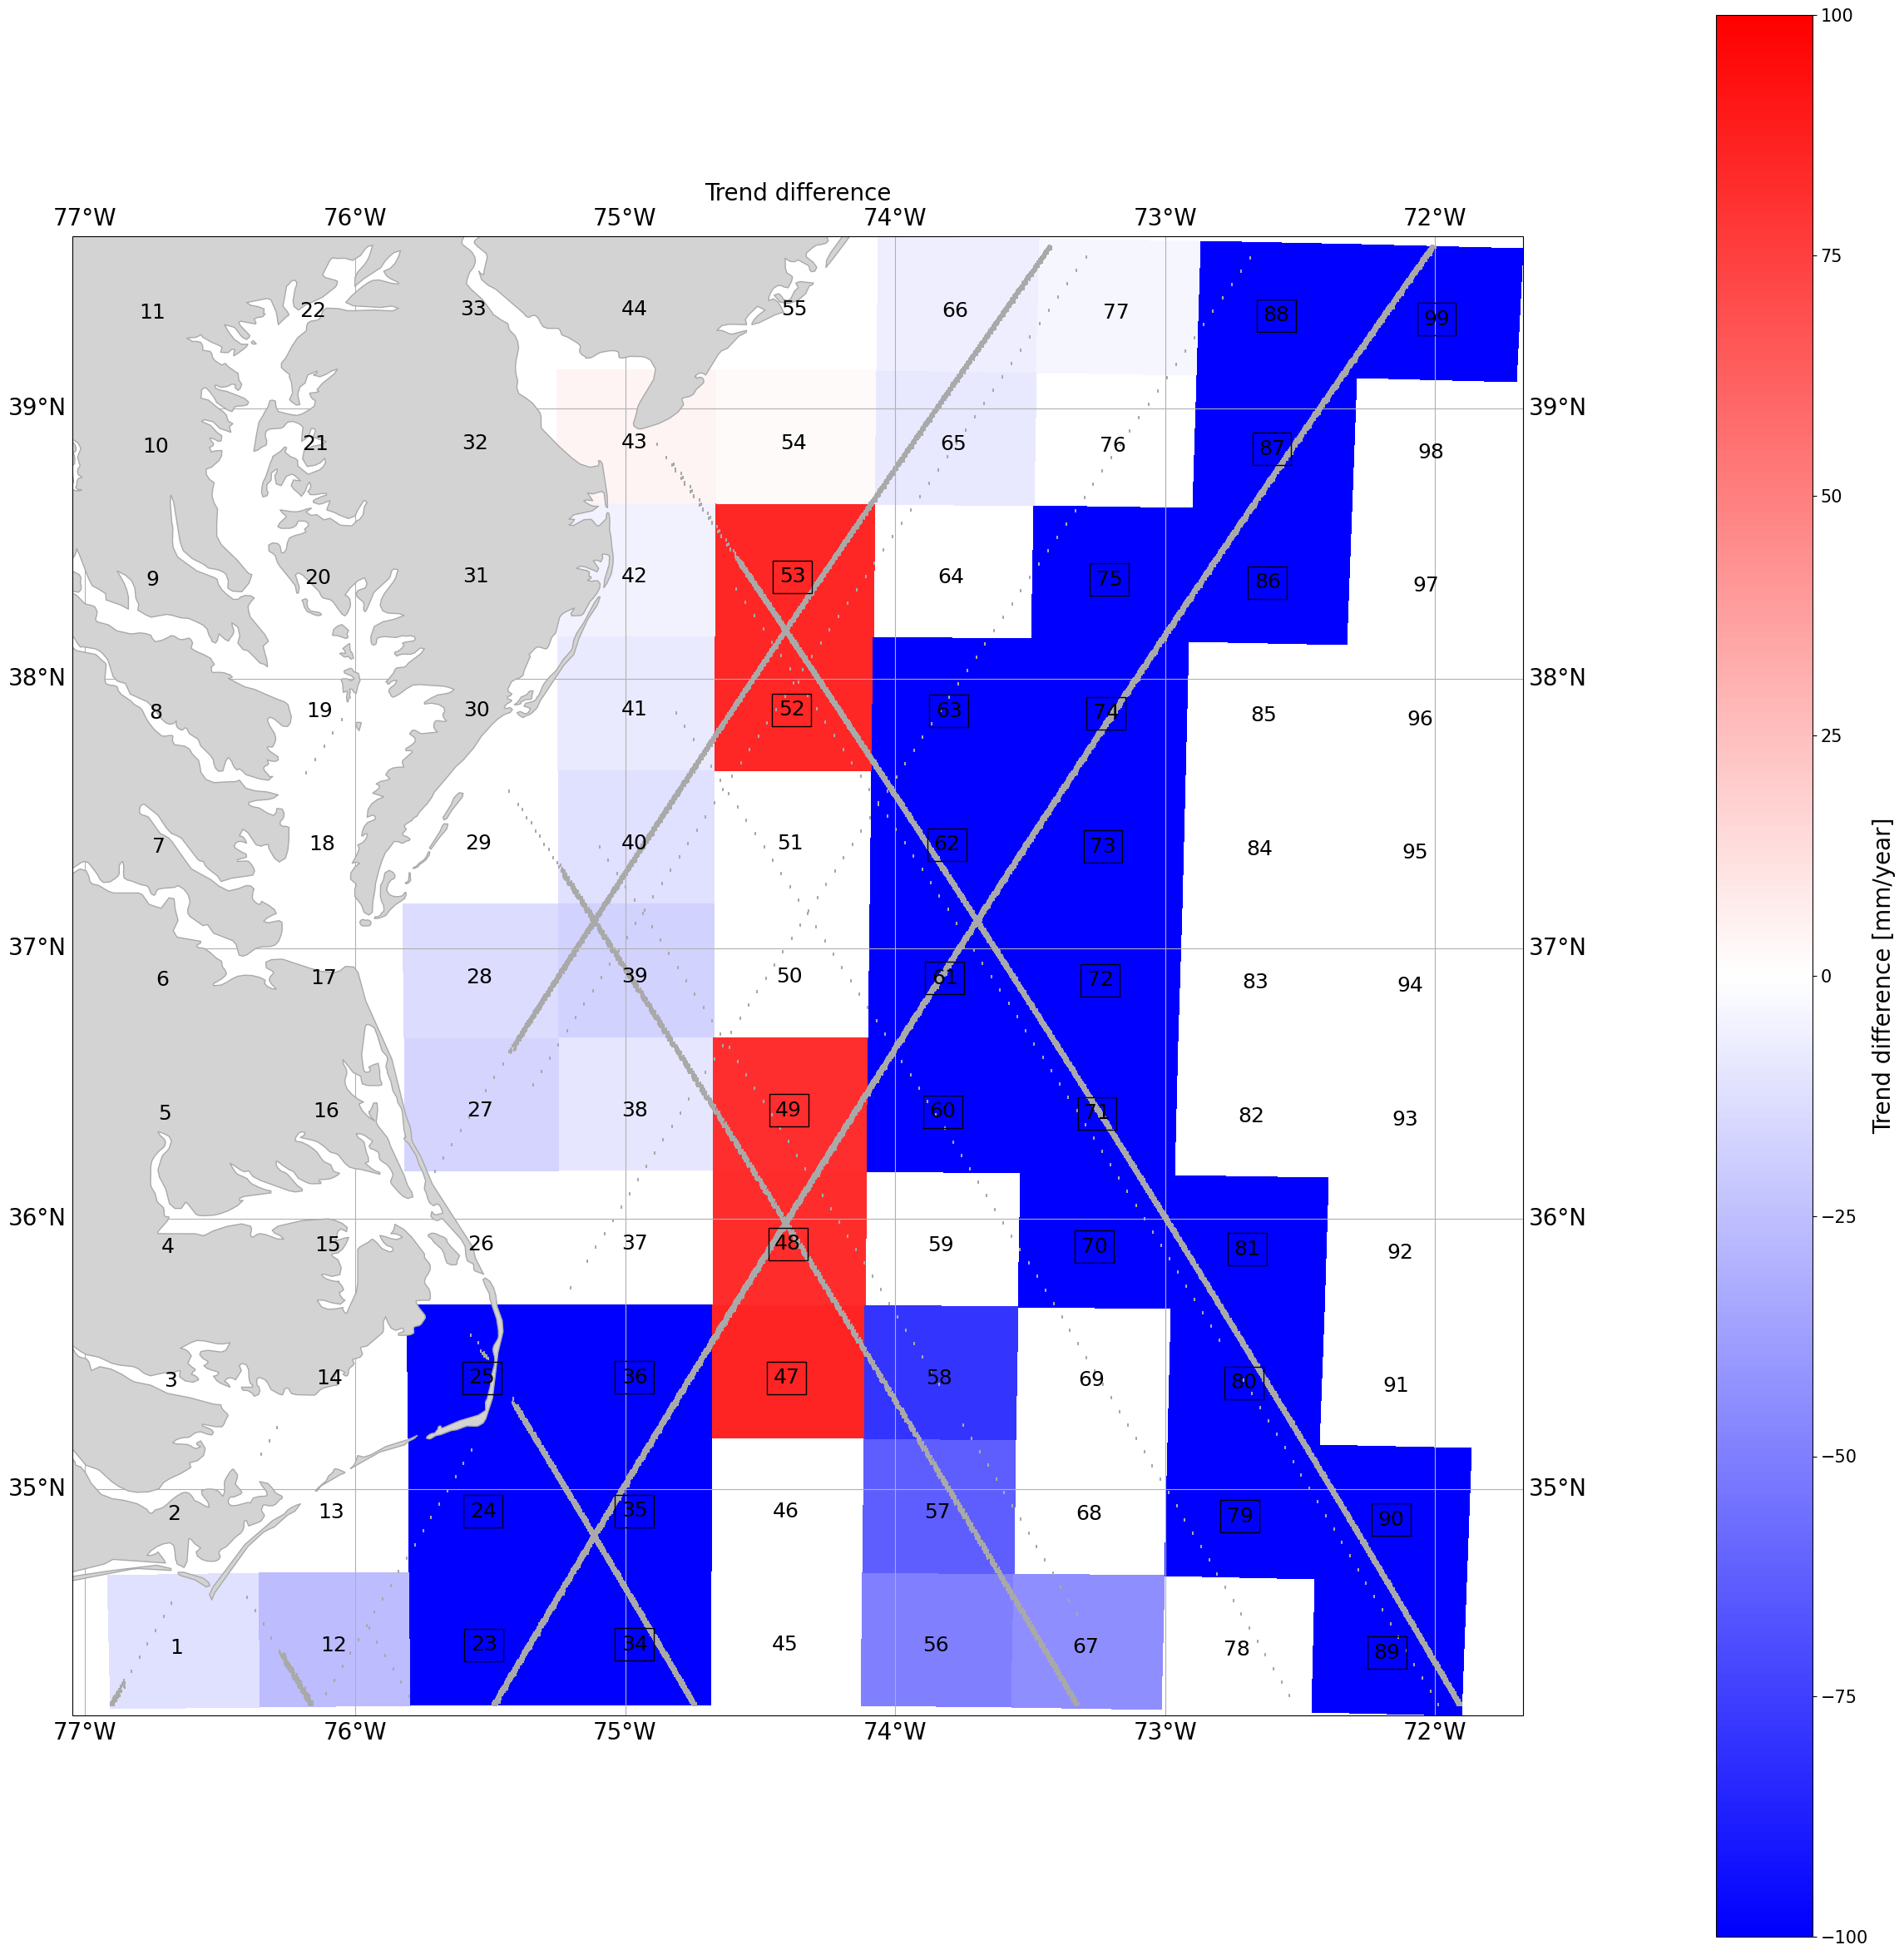

In [14]:
# Make/load timeseries
fn = f'tx_ts_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    labels = {'time':'time', 'lon':'lon', 'lat':'lat', 'sla':'ssha', 'ssh':None, 'mssh':'mss_dtu15'}
    
    tg = tg_psmsl['SSH_RLR[cm]'] - tg_psmsl['corr_ib[cm]']
    
    gridsize = {'x':50, 'y':50} # [km]
    period_covered = {'min':'1993-01-31', 'max':'2002-03-31'}
    freq_average = 'ME' # period over which to average in pd.Grouper
    
    # 'ME': month end frequency
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    
    # %matplotlib qt5
    tx_ts = CD_altimetry.get_altimetry_timeseries_with_TG(tx, labels, epsg_in, epsg_out, tg, gridsize, period_covered, freq_average)
    tx_ts.to_csv(path_output+fn)
else:
    tx_ts = pd.read_csv(path_output+fn, index_col='time', parse_dates=['time'])

## Remove bias between OpenADB and RADS timeseries

In [ ]:
tx_biased_to_ales = CD_altimetry.equalise_timeseries(tx_ts.sla_temp_av, ales_ts.sla_temp_av)

In [ ]:
combined = pd.concat([tx_biased_to_ales, ales_ts.sla_temp_av])

In [ ]:
fn = f'tp_plus_ales_epsg{epsg_out}.csv'
if (not os.path.isfile(path_output+fn)) | overwrite:
    combined.to_csv(path_output+fn)